## Import Libs

In [1]:

# Import libraries
import pandas as pd
import numpy as np
from scipy.integrate import solve_ivp

import pandas as pd
pd.set_option('display.float_format', lambda x: '%.3e' % x)

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
import seaborn as sns

# sns.set_style('darkgrid')

from pathlib import Path
# research_path = Path('../') # 'utils_functionality/')

import os
import sys
sys.path.append('../')

import utils_functionality.velocity_calculation as vc
import utils_functionality.sedimentation_calculation as sc

# from tqdm.notebook import tqdm
from tqdm.notebook import tqdm

beta here denotes exponent in the drag coefficient correction

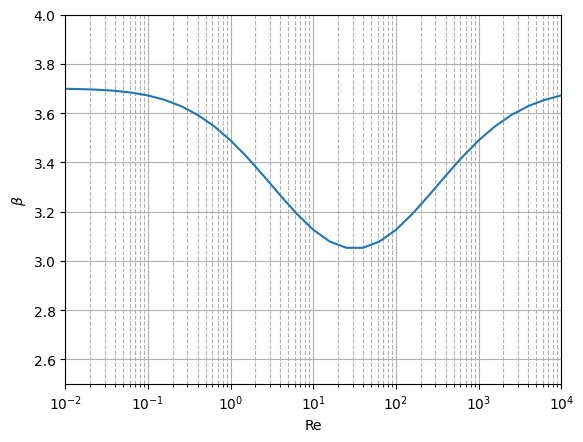

In [2]:
power = np.arange(-2, 5, step=0.2)
Re_vec = 10**power

beta = lambda Re: 3.7 - 0.65*np.exp(
        -0.5 * (1.5 - np.log10(Re))**2
    )

fig, ax = plt.subplots(1,1)
sns.lineplot(
    x=Re_vec,
    y=beta(Re_vec),
    ax=ax,
)

ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlim(1*10**-2, 10**4)
ax.set_ylim(2.5, 4)
ax.grid(which='minor', linestyle='--')
ax.grid(which='major')
ax.set_xlabel('Re')
ax.set_ylabel(r'$\beta$');

Compare with source plot [DiFelice1994VoidageFunction]:

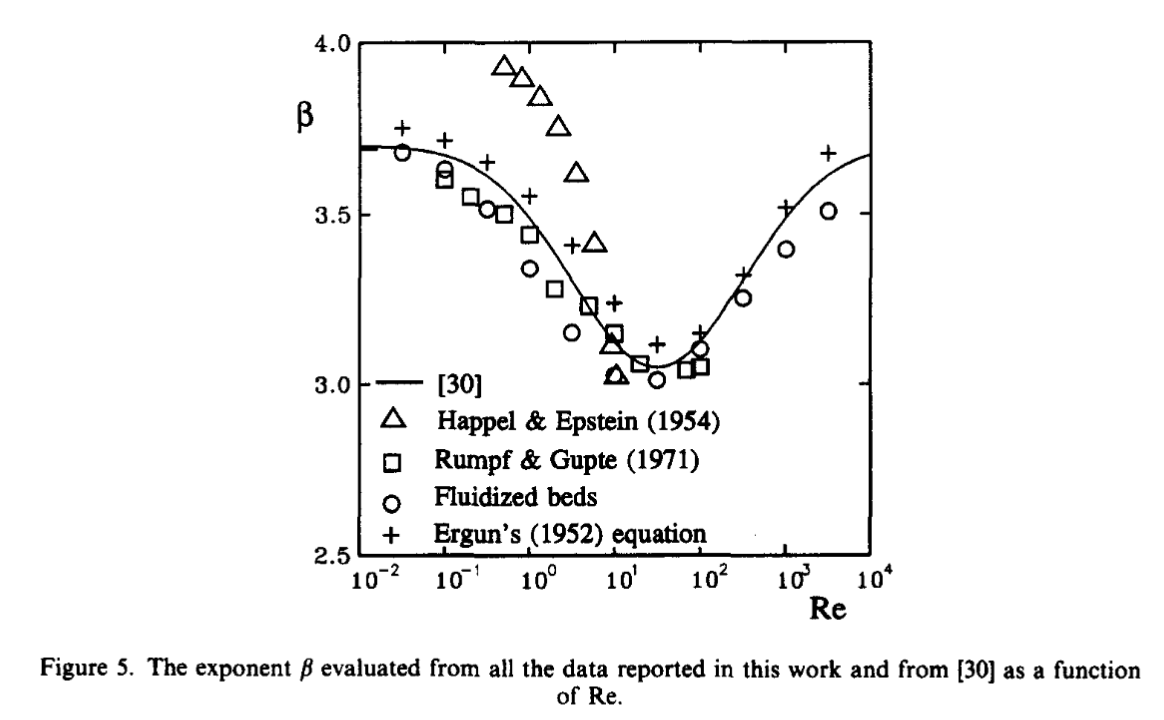

## Drag coefficient plot vs sedimentation drag coefficient plot

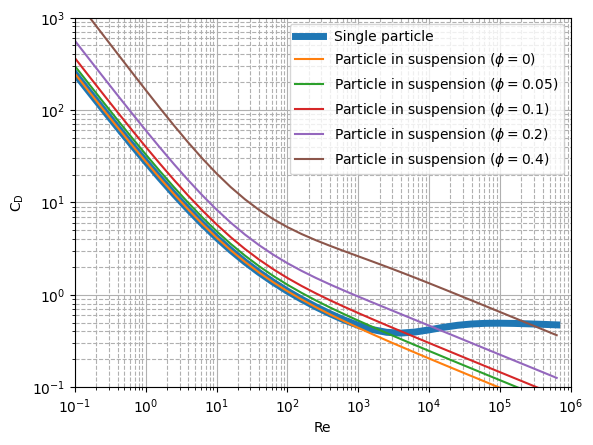

In [3]:
power = np.arange(-2, 6, step=0.2)
Re_vec = 10**power
corrections = False

fig, ax = plt.subplots(1,1)
sns.lineplot(
    x=Re_vec,
    y=vc.get_drag_coef(Re_vec),
    ax=ax,
    label='Single particle',
    linewidth=5,
)

phi = 0
sns.lineplot(
    x=Re_vec,
    y=sc.get_suspension_drag_coef(Re_vec, phi, corrections),
    ax=ax,
    label=f'Particle in suspension ($\phi=${phi})'
)

phi = 0.05
sns.lineplot(
    x=Re_vec,
    y=sc.get_suspension_drag_coef(Re_vec, phi, corrections),
    ax=ax,
    label=f'Particle in suspension ($\phi=${phi})'
)

phi = 0.10
sns.lineplot(
    x=Re_vec,
    y=sc.get_suspension_drag_coef(Re_vec, phi, corrections),
    ax=ax,
    label=f'Particle in suspension ($\phi=${phi})'
)

phi = 0.20
sns.lineplot(
    x=Re_vec,
    y=sc.get_suspension_drag_coef(Re_vec, phi, corrections),
    ax=ax,
    label=f'Particle in suspension ($\phi=${phi})'
)

phi = 0.40
sns.lineplot(
    x=Re_vec,
    y=sc.get_suspension_drag_coef(Re_vec, phi, corrections),
    ax=ax,
    label=f'Particle in suspension ($\phi=${phi})'
)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1*10**-1, 10**6)
ax.set_ylim(10**-1, 10**3)
ax.grid(which='minor', linestyle='--')
ax.grid(which='major')
ax.set_xlabel('Re')
ax.set_ylabel('$\mathrm{C}_\mathrm{D}$')
ax.legend();

# Test Sedimentation System

Consider Oz oriented down.

## Terminal velocity model

### suspension S17

In [4]:
d_p = 41.5e-6 # [m]
D_drop = 3e-3 # [m]
D_exit = 1.6e-3 # [m]
rho_l = 1180 # [kg/m^3]
mu_l = 23.1e-3 # [Pa*s]
eps_p = 2200/rho_l
phi_drop = phi0 = 0.10 # assume that initial droplet volume fraction equal to basic volume fraction of all syringe
v_interface = 0 # initial particle velocity at the interface [m/s]

g = 9.81 # [m/s^2]

init_state = np.array([v_interface, phi_drop])
# print(init_state.shape)

system = sc.IntegratedSedimentationSystem(
    init_state=init_state,
    system_parameters_init = {
        "particle_size": d_p, # particle diameter [m]
        "droplet_size": D_drop, # droplet diamter [m]
        "particle_liquid_density_ratio": eps_p, # epsilon_p = rho_p/rho_l
        "density_liquid": rho_l, # [kg/m^3]
        "viscosity_liquid": mu_l, # Dynamic viscosity [Pa*s]
        "free_fall_acceleration": g, # gravitational acceleration [m/s^2]
        "diameter_exit": D_exit, # exit diameter of the tip [m]
        "basic_volume_fraction": phi0, # initial, basic, volume fraction for the system
        "weight_basic_volume_fraction": 0.5, # coefficient of the basic volume fraction in interface volume fraction estimation
    }
)

v_term = system.get_terminal_velocity()[0]
Re = system.get_Re(v_term)[0]
print(f'v_term = {v_term:.3e}')
print(f'Re = {Re:.3e}')

Init parameters


{'particle_size': 4.15e-05,
 'droplet_size': 0.003,
 'particle_liquid_density_ratio': 1.8644067796610169,
 'density_liquid': 1180,
 'viscosity_liquid': 0.0231,
 'free_fall_acceleration': 9.81,
 'diameter_exit': 0.0016,
 'basic_volume_fraction': 0.1,
 'weight_basic_volume_fraction': 0.5,
 'height_drop': 0.007031249999999999,
 'buoyancy_acceleration': 4.548272727272727,
 'constant_of_syringe_volume_fraction': 0.05,
 'constant_of_drop_volume_fraction_change_rate': 14.222222222222223,
 'weight_droplet_volume_fraction': 0.5,
 'constant_of_Re': 2.11991341991342}

v_term = 2.806e-05
Re = 5.949e-05


In [5]:
t_span = (0, 150) # 150 s for S17, Max 457 s
t_eval = np.linspace(*t_span, num=1500)
# first_step = 1e-12
indicator_cnt = 1000
indicator_dt = (t_span[1] - t_span[0])/indicator_cnt

with tqdm(total=indicator_cnt, unit="‰") as pbar:
    numerical_results = solve_ivp(
        fun=system.compute_closed_loop_rhs,
        t_span=t_span, # s
        y0=system.init_state,
        t_eval=t_eval,
        # first_step=first_step,
        method='RK45',
        args=[pbar, indicator_dt]
    )

index_t = 0
t = numerical_results.t[index_t]
print(f'INITIAL, t= {t} s')
print(numerical_results.y[:,index_t])
print()

index_t = -1
t = numerical_results.t[index_t]
print(f'LAST, t= {t} s')
print(numerical_results.y[:,index_t])

max_Re = system.get_Re(v_interface=np.abs(numerical_results.y[0,:]).max())[0]
print(f'max_Re = {max_Re:.3e}')

  0%|          | 0/1000 [00:00<?, ?‰/s]

INITIAL, t= 0.0 s
[0.  0.1]

LAST, t= 150.0 s
[2.48430679e-05 1.56422931e-01]
max_Re = 6.137e-05


In [6]:
get_phi_term = lambda t: phi0 * (1 + v_term*t/system._parameters['height_drop'])

print(f'Last phi drop (terminal model): {get_phi_term(t=t_span[1]):.4f}')


Last phi drop (terminal model): 0.1599


Volume fraction relative difference: 2.20%
Velocity relative difference: 12.95%


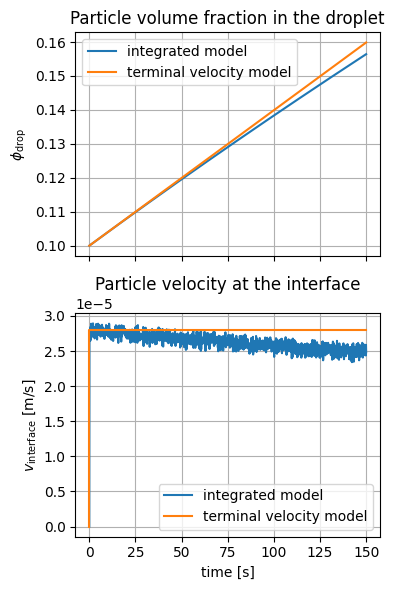

In [7]:
fig, axes = plt.subplots(2,1, figsize=(4,6), sharex=True)

time = numerical_results.t
v_interface = numerical_results.y[0,:]
phi_drop = numerical_results.y[1,:]

phi_drop_term = get_phi_term(time)

ax = axes[0]
ax.plot(
    time,
    phi_drop,
    label=f'integrated model'
)
ax.plot(
    time,
    phi_drop_term,
    label=f'terminal velocity model'
)
# ax.set_xlabel('time [s]')
ax.set_ylabel(r'$\phi_\text{drop}$')
ax.set_title('Particle volume fraction in the droplet')
ax.legend()
ax.grid()

ax = axes[1]
ax.plot(
    time,
    v_interface,
    label=f'integrated model'
)
ax.plot(
    [0, 0, time[-1]],
    [0, v_term, v_term],
    label=f'terminal velocity model'
)
ax.set_xlabel('time [s]')
ax.set_ylabel(r'$v_\text{interface}$ [m/s]')
ax.set_title('Particle velocity at the interface')
ax.legend()
ax.grid()
fig.tight_layout()

phi_diff_rel = abs(phi_drop_term[-1] - phi_drop[-1])/phi_drop[-1]
v_diff_rel = abs(v_term - v_interface[-1])/v_interface[-1]
print(f'Volume fraction relative difference: {phi_diff_rel*100:.2f}%')
print(f'Velocity relative difference: {v_diff_rel*100:.2f}%')

### suspension S15

In [14]:
d_p = 41.5e-6 # [m]
D_drop = 3e-3 # [m]
D_exit = 1.6e-3 # [m]
rho_l = 1180 # [kg/m^3]
mu_l = 23.1e-3 # [Pa*s]
eps_p = 450/rho_l
phi_drop = phi0 = 0.10 # assume that initial droplet volume fraction equal to basic volume fraction of all syringe
v_interface = 0 # initial particle velocity at the interface [m/s]

g = 9.81 # [m/s^2]

init_state = np.array([v_interface, phi_drop])
# print(init_state.shape)

system = sc.IntegratedSedimentationSystem(
    init_state=init_state,
    system_parameters_init = {
        "particle_size": d_p, # particle diameter [m]
        "droplet_size": D_drop, # droplet diamter [m]
        "particle_liquid_density_ratio": eps_p, # epsilon_p = rho_p/rho_l
        "density_liquid": rho_l, # [kg/m^3]
        "viscosity_liquid": mu_l, # Dynamic viscosity [Pa*s]
        "free_fall_acceleration": g, # gravitational acceleration [m/s^2]
        "diameter_exit": D_exit, # exit diameter of the tip [m]
        "basic_volume_fraction": phi0, # initial, basic, volume fraction for the system
        "weight_basic_volume_fraction": 0.5, # coefficient of the basic volume fraction in interface volume fraction estimation
    }
)

v_term = system.get_terminal_velocity()[0]
Re = system.get_Re(v_term)[0]
print(f'v_term = {v_term:.3e}')
print(f'Re = {Re:.3e}')

Init parameters


{'particle_size': 4.15e-05,
 'droplet_size': 0.003,
 'particle_liquid_density_ratio': 0.3813559322033898,
 'density_liquid': 1180,
 'viscosity_liquid': 0.0231,
 'free_fall_acceleration': 9.81,
 'diameter_exit': 0.0016,
 'basic_volume_fraction': 0.1,
 'weight_basic_volume_fraction': 0.5,
 'height_drop': 0.007031249999999999,
 'buoyancy_acceleration': -15.914000000000001,
 'constant_of_syringe_volume_fraction': 0.05,
 'constant_of_drop_volume_fraction_change_rate': 14.222222222222223,
 'weight_droplet_volume_fraction': 0.5,
 'constant_of_Re': 2.11991341991342}

v_term = -2.008e-05
Re = 4.257e-05


In [15]:
t_span = (0, 150) # Max 265 s for S15/S16, total Max 457 s
t_eval = np.linspace(*t_span, num=1500)
# first_step = 1e-12
indicator_cnt = 1000
indicator_dt = (t_span[1] - t_span[0])/indicator_cnt

with tqdm(total=indicator_cnt, unit="‰") as pbar:
    numerical_results = solve_ivp(
        fun=system.compute_closed_loop_rhs,
        t_span=t_span, # s
        y0=system.init_state,
        t_eval=t_eval,
        # first_step=first_step,
        method='RK45',
        args=[pbar, indicator_dt]
    )

index_t = 0
t = numerical_results.t[index_t]
print(f'INITIAL, t= {t} s')
print(numerical_results.y[:,index_t])
print()

index_t = -1
t = numerical_results.t[index_t]
print(f'LAST, t= {t} s')
print(numerical_results.y[:,index_t])

max_Re = system.get_Re(v_interface=np.results(numerical_results.y[0,:]).max())[0]
print(f'max_Re = {max_Re:.3e}')


get_phi_term = lambda t: phi0 * (1 + v_term*t/system._parameters['height_drop'])
print(f'Last phi drop (terminal model): {get_phi_term(t=t_span[1]):.4f}')

  0%|          | 0/1000 [00:00<?, ?‰/s]

INITIAL, t= 0.0 s
[0.  0.1]

LAST, t= 150.0 s
[-1.98362611e-05  5.71554664e-02]
max_Re = 0.000e+00
Last phi drop (terminal model): 0.0572


Volume fraction relative difference: 0.00%
Velocity relative difference: -1.25%


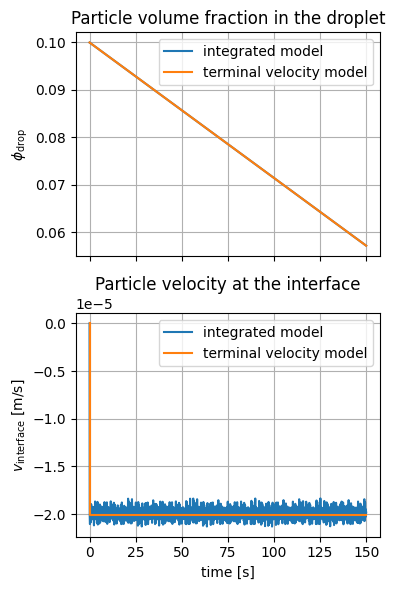

In [16]:
fig, axes = plt.subplots(2,1, figsize=(4,6), sharex=True)

time = numerical_results.t
v_interface = numerical_results.y[0,:]
phi_drop = numerical_results.y[1,:]

phi_drop_term = get_phi_term(time)

ax = axes[0]
ax.plot(
    time,
    phi_drop,
    label=f'integrated model'
)
ax.plot(
    time,
    phi_drop_term,
    label=f'terminal velocity model'
)
# ax.set_xlabel('time [s]')
ax.set_ylabel(r'$\phi_\text{drop}$')
ax.set_title('Particle volume fraction in the droplet')
ax.legend()
ax.grid()

ax = axes[1]
ax.plot(
    time,
    v_interface,
    label=f'integrated model'
)
ax.plot(
    [0, 0, time[-1]],
    [0, v_term, v_term],
    label=f'terminal velocity model'
)
ax.set_xlabel('time [s]')
ax.set_ylabel(r'$v_\text{interface}$ [m/s]')
ax.set_title('Particle velocity at the interface')
ax.legend()
ax.grid()
fig.tight_layout()

phi_diff_rel = abs(phi_drop_term[-1] - phi_drop[-1])/phi_drop[-1]
v_diff_rel = abs(v_term - v_interface[-1])/v_interface[-1]
print(f'Volume fraction relative difference: {phi_diff_rel*100:.2f}%')
print(f'Velocity relative difference: {v_diff_rel*100:.2f}%')

In [19]:
system._parameters['height_drop']

0.007031249999999999

In [20]:
distance = v_term * 265
system._parameters['height_drop'] + distance

0.001709162508588732

In [21]:
get_phi_term(t=265)

0.024308089011039747

### suspension S7

In [22]:
d_p = 137.5e-6 # [m]
D_drop = 3e-3 # [m]
D_exit = 1.6e-3 # [m]
rho_l = 1000 # [kg/m^3]
mu_l = 1.04e-3 # [Pa*s]
eps_p = 1001/rho_l
phi_drop = phi0 = 0.10 # assume that initial droplet volume fraction equal to basic volume fraction of all syringe
v_interface = 0 # initial particle velocity at the interface [m/s]

g = 9.81 # [m/s^2]

init_state = np.array([v_interface, phi_drop])
# print(init_state.shape)

system = sc.IntegratedSedimentationSystem(
    init_state=init_state,
    system_parameters_init = {
        "particle_size": d_p, # particle diameter [m]
        "droplet_size": D_drop, # droplet diamter [m]
        "particle_liquid_density_ratio": eps_p, # epsilon_p = rho_p/rho_l
        "density_liquid": rho_l, # [kg/m^3]
        "viscosity_liquid": mu_l, # Dynamic viscosity [Pa*s]
        "free_fall_acceleration": g, # gravitational acceleration [m/s^2]
        "diameter_exit": D_exit, # exit diameter of the tip [m]
        "basic_volume_fraction": phi0, # initial, basic, volume fraction for the system
        "weight_basic_volume_fraction": 0.5, # coefficient of the basic volume fraction in interface volume fraction estimation
    }
)

v_term = system.get_terminal_velocity()[0]
Re = system.get_Re(v_term)[0]
print(f'v_term = {v_term:.3e}')
print(f'Re = {Re:.3e}')

Init parameters


{'particle_size': 0.0001375,
 'droplet_size': 0.003,
 'particle_liquid_density_ratio': 1.001,
 'density_liquid': 1000,
 'viscosity_liquid': 0.00104,
 'free_fall_acceleration': 9.81,
 'diameter_exit': 0.0016,
 'basic_volume_fraction': 0.1,
 'weight_basic_volume_fraction': 0.5,
 'height_drop': 0.007031249999999999,
 'buoyancy_acceleration': 0.00980019980019838,
 'constant_of_syringe_volume_fraction': 0.05,
 'constant_of_drop_volume_fraction_change_rate': 14.222222222222223,
 'weight_droplet_volume_fraction': 0.5,
 'constant_of_Re': 132.21153846153848}

v_term = 6.701e-06
Re = 8.860e-04


## Test with simplifyed calculations

Constants are predetermined

In [5]:
d_p = 41.5e-6 # [m]
D_drop = 3e-3 # [m]
D_exit = 1.6e-3 # [m]
rho_l = 1180 # [kg/m^3]
mu_l = 23.1e-3 # [Pa*s]
eps_p = 2200/rho_l
phi_drop = phi0 = 0.10 # assume that initial droplet volume fraction equal to basic volume fraction of all syringe
v_interface = 0 # initial particle velocity at the interface [m/s]

g = 9.81 # [m/s^2]

init_state = np.array([v_interface, phi_drop])
# print(init_state.shape)

system = sc.IntegratedSedimentationSystem(
    init_state=init_state,
    system_parameters_init = {
        "particle_size": d_p, # particle diameter [m]
        "droplet_size": D_drop, # droplet diamter [m]
        "particle_liquid_density_ratio": eps_p, # epsilon_p = rho_p/rho_l
        "density_liquid": rho_l, # [kg/m^3]
        "viscosity_liquid": mu_l, # Dynamic viscosity [Pa*s]
        "free_fall_acceleration": g, # gravitational acceleration [m/s^2]
        "diameter_exit": D_exit, # exit diameter of the tip [m]
        "basic_volume_fraction": phi0, # initial, basic, volume fraction for the system
        "weight_basic_volume_fraction": 0.5, # coefficient of the basic volume fraction in interface volume fraction estimation
    }
)

t_span = (0, 60) # 150 s for S17, Max 457 s
t_eval = np.linspace(*t_span, num=1000)
# first_step = 1e-12
indicator_cnt = 1000
indicator_dt = (t_span[1] - t_span[0])/indicator_cnt

with tqdm(total=indicator_cnt, unit="‰") as pbar:
    numerical_results = solve_ivp(
        fun=system.compute_closed_loop_rhs,
        t_span=t_span, # s
        y0=system.init_state,
        t_eval=t_eval,
        # first_step=first_step,
        method='RK45',
        args=[pbar, indicator_dt]
    )

index_t = 0
t = numerical_results.t[index_t]
print(f'INITIAL, t= {t} s')
print(numerical_results.y[:,index_t])
print()

index_t = -1
t = numerical_results.t[index_t]
print(f'LAST, t= {t} s')
print(numerical_results.y[:,index_t])

max_Re = system.get_Re(v_interface=numerical_results.y[0,:].max())[0]
print(f'max_Re = {max_Re:.3e}')

Init parameters


{'particle_size': 4.15e-05,
 'droplet_size': 0.003,
 'particle_liquid_density_ratio': 1.8644067796610169,
 'density_liquid': 1180,
 'viscosity_liquid': 0.0231,
 'free_fall_acceleration': 9.81,
 'diameter_exit': 0.0016,
 'basic_volume_fraction': 0.1,
 'weight_basic_volume_fraction': 0.5,
 'height_drop': 0.007031249999999999,
 'buoyancy_acceleration': 4.548272727272727,
 'constant_of_syringe_volume_fraction': 0.05,
 'constant_of_drop_volume_fraction_change_rate': 14.222222222222223,
 'weight_droplet_volume_fraction': 0.5,
 'constant_of_Re': 2.11991341991342}

  0%|          | 0/1000 [00:00<?, ?‰/s]

INITIAL, t= 0.0 s
[0.  0.1]

LAST, t= 60.0 s
[2.65749778e-05 1.23372063e-01]
max_Re = 6.178e-05


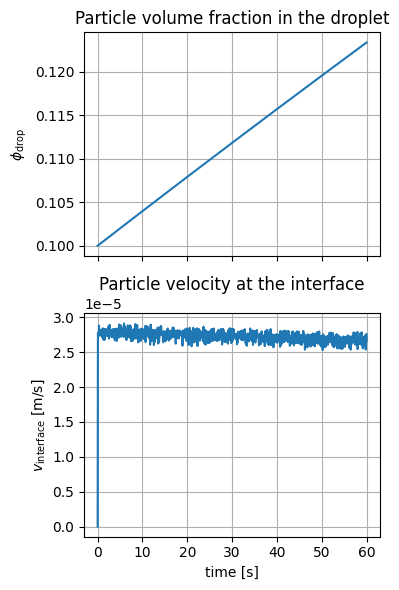

In [6]:
fig, axes = plt.subplots(2,1, figsize=(4,6), sharex=True)

time = numerical_results.t
v_interface = numerical_results.y[0,:]
phi_drop = numerical_results.y[1,:]

ax = axes[0]
ax.plot(
    time,
    phi_drop,
    label=f'particle volume fraction in the droplet'
)
# ax.set_xlabel('time [s]')
ax.set_ylabel(r'$\phi_\text{drop}$')
ax.set_title('Particle volume fraction in the droplet')
# ax.legend()
ax.grid()

ax = axes[1]
ax.plot(
    time,
    v_interface,
    label=f'particle velocity at the interface'
)
ax.set_xlabel('time [s]')
ax.set_ylabel(r'$v_\text{interface}$ [m/s]')
ax.set_title('Particle velocity at the interface')
# ax.legend()
ax.grid()
fig.tight_layout()

Half a minute less calculation! 7:36 vs 8:13 vs 9:04 vs 10:08

But plot is the same, as below

## Test with beta = 3.7 (corrections only if Re > 10^-2)

In [4]:
d_p = 41.5e-6 # [m]
D_drop = 3e-3 # [m]
D_exit = 1.6e-3 # [m]
rho_l = 1180 # [kg/m^3]
mu_l = 23.1e-3 # [Pa*s]
eps_p = 2200/rho_l
phi_drop = phi0 = 0.10 # assume that initial droplet volume fraction equal to basic volume fraction of all syringe
v_interface = 0 # initial particle velocity at the interface [m/s]

g = 9.81 # [m/s^2]

init_state = np.array([v_interface, phi_drop])
# print(init_state.shape)

system = sc.IntegratedSedimentationSystem(
    init_state=init_state,
    system_parameters_init = {
        "particle_size": d_p, # particle diameter [m]
        "droplet_size": D_drop, # droplet diamter [m]
        "particle_liquid_density_ratio": eps_p, # epsilon_p = rho_p/rho_l
        "density_liquid": rho_l, # [kg/m^3]
        "viscosity_liquid": mu_l, # Dynamic viscosity [Pa*s]
        "free_fall_acceleration": g, # gravitational acceleration [m/s^2]
        "diameter_exit": D_exit, # exit diameter of the tip [m]
        "basic_volume_fraction": phi0, # initial, basic, volume fraction for the system
        "weight_basic_volume_fraction": 0.5, # coefficient of the basic volume fraction in interface volume fraction estimation
    }
)

t_span = (0, 60)
t_eval = np.linspace(*t_span, num=1000)
# first_step = 1e-12
indicator_cnt = 1000
indicator_dt = (t_span[1] - t_span[0])/indicator_cnt

with tqdm(total=indicator_cnt, unit="‰") as pbar:
    numerical_results = solve_ivp(
        fun=system.compute_closed_loop_rhs,
        t_span=t_span, # s
        y0=system.init_state,
        t_eval=t_eval,
        # first_step=first_step,
        method='RK45',
        args=[pbar, indicator_dt]
    )

index_t = 0
t = numerical_results.t[index_t]
print(f'INITIAL, t= {t} s')
print(numerical_results.y[:,index_t])
print()

index_t = -1
t = numerical_results.t[index_t]
print(f'LAST, t= {t} s')
print(numerical_results.y[:,index_t])

Init parameters


{'particle_size': 4.15e-05,
 'droplet_size': 0.003,
 'particle_liquid_density_ratio': 1.8644067796610169,
 'density_liquid': 1180,
 'viscosity_liquid': 0.0231,
 'free_fall_acceleration': 9.81,
 'diameter_exit': 0.0016,
 'basic_volume_fraction': 0.1,
 'weight_basic_volume_fraction': 0.5,
 'height_drop': 0.007031249999999999}

  0%|          | 0/1000 [00:00<?, ?‰/s]

INITIAL, t= 0.0 s
[0.  0.1]

LAST, t= 60.0 s
[2.65749771e-05 1.23372063e-01]


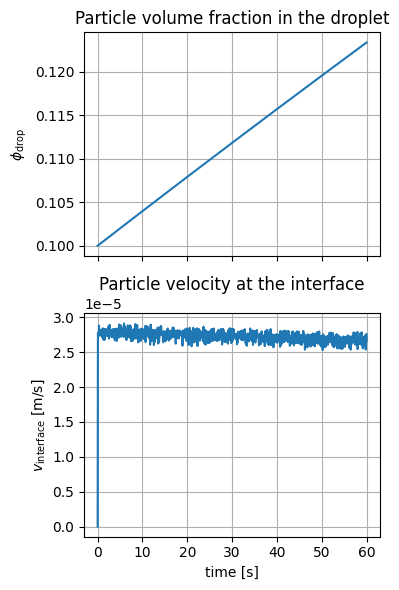

In [5]:
fig, axes = plt.subplots(2,1, figsize=(4,6), sharex=True)

time = numerical_results.t
v_interface = numerical_results.y[0,:]
phi_drop = numerical_results.y[1,:]

ax = axes[0]
ax.plot(
    time,
    phi_drop,
    label=f'particle volume fraction in the droplet'
)
# ax.set_xlabel('time [s]')
ax.set_ylabel(r'$\phi_\text{drop}$')
ax.set_title('Particle volume fraction in the droplet')
# ax.legend()
ax.grid()

ax = axes[1]
ax.plot(
    time,
    v_interface,
    label=f'particle velocity at the interface'
)
ax.set_xlabel('time [s]')
ax.set_ylabel(r'$v_\text{interface}$ [m/s]')
ax.set_title('Particle velocity at the interface')
# ax.legend()
ax.grid()
fig.tight_layout()

One more minute less calculation! 8:13 vs 9:04 vs 10:08

But plot is the same, as below

## Test with basic drag force coefficient

In [4]:
d_p = 41.5e-6 # [m]
D_drop = 3e-3 # [m]
D_exit = 1.6e-3 # [m]
rho_l = 1180 # [kg/m^3]
mu_l = 23.1e-3 # [Pa*s]
eps_p = 2200/rho_l
phi_drop = phi0 = 0.10 # assume that initial droplet volume fraction equal to basic volume fraction of all syringe
v_interface = 0 # initial particle velocity at the interface [m/s]

g = 9.81 # [m/s^2]

init_state = np.array([v_interface, phi_drop])
# print(init_state.shape)

system = sc.IntegratedSedimentationSystem(
    init_state=init_state,
    system_parameters_init = {
        "particle_size": d_p, # particle diameter [m]
        "droplet_size": D_drop, # droplet diamter [m]
        "particle_liquid_density_ratio": eps_p, # epsilon_p = rho_p/rho_l
        "density_liquid": rho_l, # [kg/m^3]
        "viscosity_liquid": mu_l, # Dynamic viscosity [Pa*s]
        "free_fall_acceleration": g, # gravitational acceleration [m/s^2]
        "diameter_exit": D_exit, # exit diameter of the tip [m]
        "basic_volume_fraction": phi0, # initial, basic, volume fraction for the system
        "weight_basic_volume_fraction": 0.5, # coefficient of the basic volume fraction in interface volume fraction estimation
    }
)

t_span = (0, 60)
t_eval = np.linspace(*t_span, num=1000)
# first_step = 1e-12
indicator_cnt = 1000
indicator_dt = (t_span[1] - t_span[0])/indicator_cnt

with tqdm(total=indicator_cnt, unit="‰") as pbar:
    numerical_results = solve_ivp(
        fun=system.compute_closed_loop_rhs,
        t_span=t_span, # s
        y0=system.init_state,
        t_eval=t_eval,
        # first_step=first_step,
        method='RK45',
        args=[pbar, indicator_dt]
    )

index_t = 0
t = numerical_results.t[index_t]
print(f'INITIAL, t= {t} s')
print(numerical_results.y[:,index_t])
print()

index_t = -1
t = numerical_results.t[index_t]
print(f'LAST, t= {t} s')
print(numerical_results.y[:,index_t])

Init parameters


{'particle_size': 4.15e-05,
 'droplet_size': 0.003,
 'particle_liquid_density_ratio': 1.8644067796610169,
 'density_liquid': 1180,
 'viscosity_liquid': 0.0231,
 'free_fall_acceleration': 9.81,
 'diameter_exit': 0.0016,
 'basic_volume_fraction': 0.1,
 'weight_basic_volume_fraction': 0.5,
 'height_drop': 0.007031249999999999}

  0%|          | 0/1000 [00:00<?, ?‰/s]

INITIAL, t= 0.0 s
[0.  0.1]

LAST, t= 60.0 s
[2.65677091e-05 1.23372063e-01]


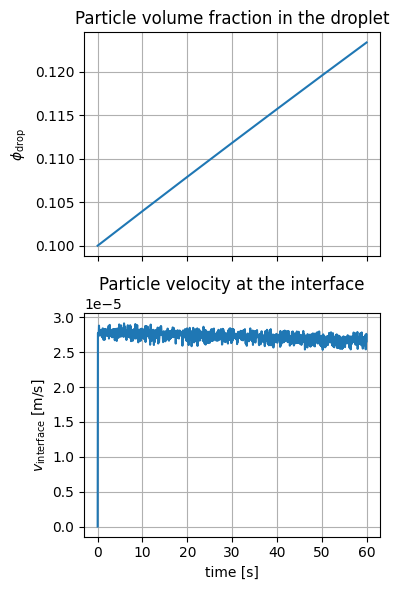

In [5]:
fig, axes = plt.subplots(2,1, figsize=(4,6), sharex=True)

time = numerical_results.t
v_interface = numerical_results.y[0,:]
phi_drop = numerical_results.y[1,:]

ax = axes[0]
ax.plot(
    time,
    phi_drop,
    label=f'particle volume fraction in the droplet'
)
# ax.set_xlabel('time [s]')
ax.set_ylabel(r'$\phi_\text{drop}$')
ax.set_title('Particle volume fraction in the droplet')
# ax.legend()
ax.grid()

ax = axes[1]
ax.plot(
    time,
    v_interface,
    label=f'particle velocity at the interface'
)
ax.set_xlabel('time [s]')
ax.set_ylabel(r'$v_\text{interface}$ [m/s]')
ax.set_title('Particle velocity at the interface')
# ax.legend()
ax.grid()
fig.tight_layout()

One minute less calculation! But plot is the same, as below

In [8]:

Re = vc.get_Re(
    velocity=np.array([2.5e-5, 3.0e-5]),
    diameter=d_p,
    density=rho_l,
    viscosity=mu_l
)
print(Re)
3.7 - 0.65*np.exp(
    -0.5 * (1.5 - np.log10(np.array([1e-3, 1e-2, 1e-1])))**2
)

[5.29978355e-05 6.35974026e-05]


array([3.69997396, 3.69857813, 3.67144099])

## Test with Full drag force coefficient:

In [4]:
d_p = 41.5e-6 # [m]
D_drop = 3e-3 # [m]
D_exit = 1.6e-3 # [m]
rho_l = 1180 # [kg/m^3]
mu_l = 23.1e-3 # [Pa*s]
eps_p = 2200/rho_l
phi_drop = phi0 = 0.10 # assume that initial droplet volume fraction equal to basic volume fraction of all syringe
v_interface = 0 # initial particle velocity at the interface [m/s]

g = 9.81 # [m/s^2]

init_state = np.array([v_interface, phi_drop])
# print(init_state.shape)

system = sc.IntegratedSedimentationSystem(
    init_state=init_state,
    system_parameters_init = {
        "particle_size": d_p, # particle diameter [m]
        "droplet_size": D_drop, # droplet diamter [m]
        "particle_liquid_density_ratio": eps_p, # epsilon_p = rho_p/rho_l
        "density_liquid": rho_l, # [kg/m^3]
        "viscosity_liquid": mu_l, # Dynamic viscosity [Pa*s]
        "free_fall_acceleration": g, # gravitational acceleration [m/s^2]
        "diameter_exit": D_exit, # exit diameter of the tip [m]
        "basic_volume_fraction": phi0, # initial, basic, volume fraction for the system
        "weight_basic_volume_fraction": 0.5, # coefficient of the basic volume fraction in interface volume fraction estimation
    }
)

t_span = (0, 60)
t_eval = np.linspace(*t_span, num=1000)
# first_step = 1e-12
indicator_cnt = 1000
indicator_dt = (t_span[1] - t_span[0])/indicator_cnt

with tqdm(total=indicator_cnt, unit="‰") as pbar:
    numerical_results = solve_ivp(
        fun=system.compute_closed_loop_rhs,
        t_span=t_span, # s
        y0=system.init_state,
        t_eval=t_eval,
        # first_step=first_step,
        method='RK45',
        args=[pbar, indicator_dt]
    )

index_t = 0
t = numerical_results.t[index_t]
print(f'INITIAL, t= {t} s')
print(numerical_results.y[:,index_t])
print()

index_t = -1
t = numerical_results.t[index_t]
print(f'LAST, t= {t} s')
print(numerical_results.y[:,index_t])

Init parameters


{'particle_size': 4.15e-05,
 'droplet_size': 0.003,
 'particle_liquid_density_ratio': 1.8644067796610169,
 'density_liquid': 1180,
 'viscosity_liquid': 0.0231,
 'free_fall_acceleration': 9.81,
 'diameter_exit': 0.0016,
 'basic_volume_fraction': 0.1,
 'weight_basic_volume_fraction': 0.5,
 'height_drop': 0.007031249999999999}

  0%|          | 0/1000 [00:00<?, ?‰/s]

INITIAL, t= 0.0 s
[0.  0.1]

LAST, t= 60.0 s
[2.65677085e-05 1.23372063e-01]


Longer, than previous one

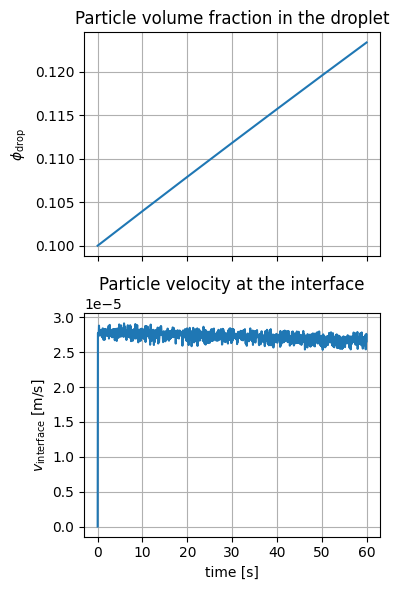

In [10]:
fig, axes = plt.subplots(2,1, figsize=(4,6), sharex=True)

time = numerical_results.t
v_interface = numerical_results.y[0,:]
phi_drop = numerical_results.y[1,:]

ax = axes[0]
ax.plot(
    time,
    phi_drop,
    label=f'particle volume fraction in the droplet'
)
# ax.set_xlabel('time [s]')
ax.set_ylabel(r'$\phi_\text{drop}$')
ax.set_title('Particle volume fraction in the droplet')
# ax.legend()
ax.grid()

ax = axes[1]
ax.plot(
    time,
    v_interface,
    label=f'particle velocity at the interface'
)
ax.set_xlabel('time [s]')
ax.set_ylabel(r'$v_\text{interface}$ [m/s]')
ax.set_title('Particle velocity at the interface')
# ax.legend()
ax.grid()
fig.tight_layout()

Plot is the same